Data Analysis

In [1]:
import pandas as pd 
ratings = pd.read_csv(
    "./ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

In [2]:
print(ratings.shape)
print(ratings.head())

(100000, 4)
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596


In [3]:
print("Users:", ratings["user_id"].nunique())
print("Movies:", ratings["movie_id"].nunique())
print("Ratings:", len(ratings))

Users: 943
Movies: 1682
Ratings: 100000


In [4]:
user_counts = ratings.groupby("user_id").size()

print(user_counts.describe())

movie_counts = ratings.groupby("movie_id").size()

print(movie_counts.describe())

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64
count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
dtype: float64


Conversion of data into graph 

In [5]:
num_users = ratings["user_id"].nunique()

user_mapping = {
    uid: idx
    for idx, uid in enumerate(ratings["user_id"].unique())
}

movie_mapping = {
    mid: idx + num_users
    for idx, mid in enumerate(ratings["movie_id"].unique())
}

In [6]:
print("User 196 ->", user_mapping[196])
print("Movie 242 ->", movie_mapping[242])

User 196 -> 0
Movie 242 -> 943


In [7]:
edges = []

for _, row in ratings.iterrows():
    user_node = user_mapping[row["user_id"]]
    movie_node = movie_mapping[row["movie_id"]]

    edges.append([user_node, movie_node])

In [8]:
import torch

edge_index = torch.tensor(edges).t().contiguous()

print(edge_index.shape)

torch.Size([2, 100000])


In [9]:
print(edge_index[:, :10])

tensor([[  0,   1,   2,   3,   4,   5,   6,   7,   8,   9],
        [943, 944, 945, 946, 947, 948, 949, 950, 951, 952]])


In [10]:
reverse_edges = edge_index.flip(0)

edge_index = torch.cat(
    [edge_index, reverse_edges],
    dim=1
)

print(edge_index.shape)

torch.Size([2, 200000])


In [11]:
num_nodes = len(user_mapping) + len(movie_mapping)

print(num_nodes)

2625


Create Node feature

In [12]:
import torch

x = torch.eye(num_nodes)

In [13]:
from torch_geometric.data import Data

data = Data(
    x=x,
    edge_index=edge_index
)

print(data)

d:\SIST\graphnn\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data(x=[2625, 2625], edge_index=[2, 200000])


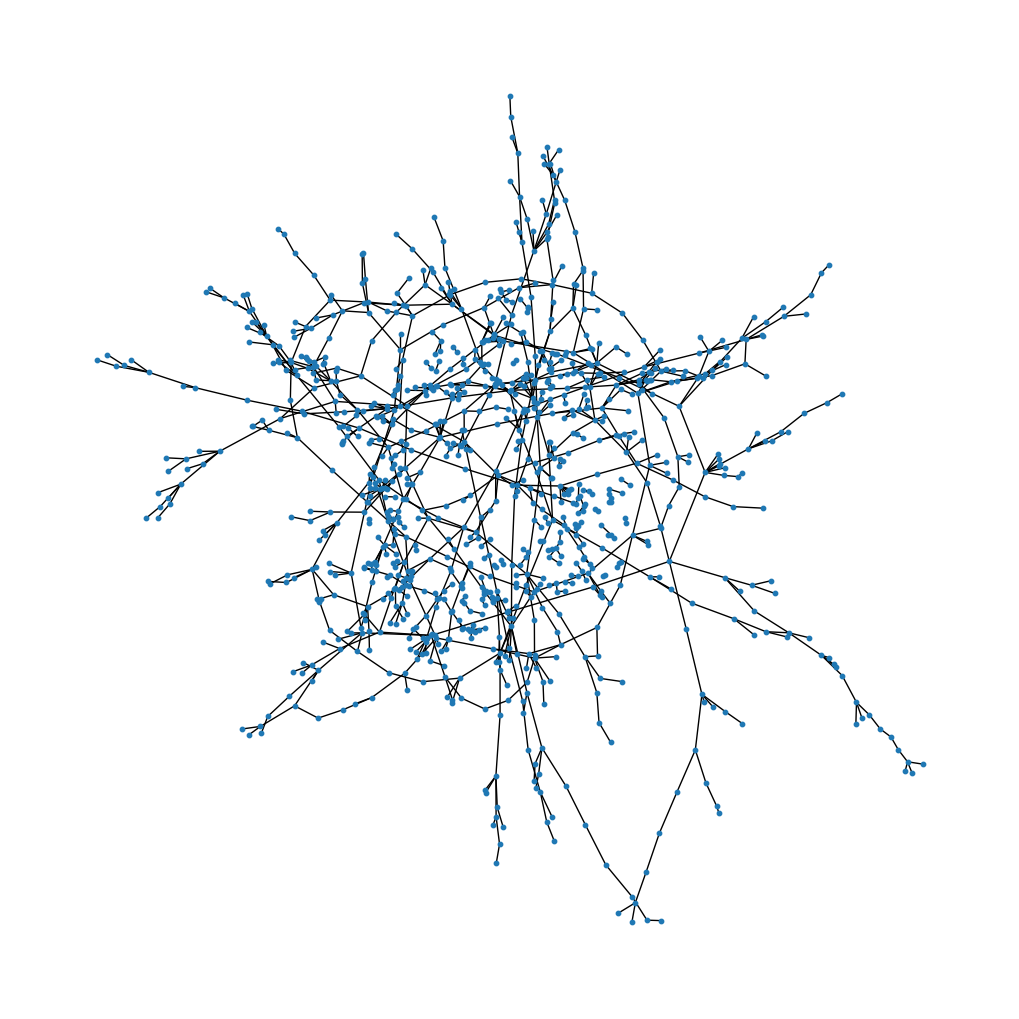

In [14]:
import random
import networkx as nx
import matplotlib.pyplot as plt

sample_indices = torch.randperm(edge_index.shape[1])[:1000]
sample_edges = edge_index[:, sample_indices]

G = nx.Graph()
G.add_edges_from(sample_edges.t().tolist())

plt.figure(figsize=(10,10))
nx.draw(G, node_size=10)
plt.show()

Train test split

In [15]:
from torch_geometric.transforms import RandomLinkSplit
x = torch.randn(num_nodes, 64)

data = Data(
    x=x,
    edge_index=edge_index
)

transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=True,
    add_negative_train_samples=True
)

train_data, val_data, test_data = transform(data)

In [16]:
import torch
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

    def encode(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x

    def decode(self, z, edge_label_index):

        src = z[edge_label_index[0]]
        dst = z[edge_label_index[1]]

        return (src * dst).sum(dim=-1)

In [17]:
x = torch.randn(num_nodes, 64)
model = GraphSAGE(
    in_channels=64,
    hidden_channels=64
)

In [18]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

In [19]:
def train():

    model.train()

    optimizer.zero_grad()

    z = model.encode(
        train_data.x,
        train_data.edge_index
    )

    pred = model.decode(
        z,
        train_data.edge_label_index
    )

    loss = F.binary_cross_entropy_with_logits(
        pred,
        train_data.edge_label.float()
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [21]:
for epoch in range(1, 51):

    loss = train()

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch}, Loss {loss:.4f}"
        )

Epoch 5, Loss 0.8638
Epoch 10, Loss 0.7052
Epoch 15, Loss 0.6955
Epoch 20, Loss 0.6900
Epoch 25, Loss 0.6811
Epoch 30, Loss 0.6678
Epoch 35, Loss 0.6514
Epoch 40, Loss 0.6328
Epoch 45, Loss 0.6189
Epoch 50, Loss 0.6078


In [22]:
z = model.encode(
    train_data.x,
    train_data.edge_index
)

print(z.shape)

torch.Size([2625, 64])


Evaluation

In [23]:
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def evaluate(split_data):

    model.eval()

    z = model.encode(
        split_data.x,
        split_data.edge_index
    )

    pred = model.decode(
        z,
        split_data.edge_label_index
    )

    pred = torch.sigmoid(pred)

    auc = roc_auc_score(
        split_data.edge_label.cpu(),
        pred.cpu()
    )

    return auc

In [24]:
val_auc = evaluate(val_data)
test_auc = evaluate(test_data)

print("Validation AUC:", val_auc)
print("Test AUC:", test_auc)

Validation AUC: 0.79805307
Test AUC: 0.7968922900000001


In [25]:
import pandas as pd

movies = pd.read_csv(
    "./ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

movie_titles = dict(zip(movies[0], movies[1]))

Recommendations

In [26]:
import torch

user_id = 196

user_node = user_mapping[user_id]

user_embedding = z[user_node]

watched_movies = set(
    ratings[
        ratings["user_id"] == user_id
    ]["movie_id"]
)

scores = []

for movie_id, movie_node in movie_mapping.items():

    if movie_id in watched_movies:
        continue

    movie_embedding = z[movie_node]

    score = torch.dot(
        user_embedding,
        movie_embedding
    ).item()

    scores.append((movie_id, score))

scores.sort(
    key=lambda x: x[1],
    reverse=True
)

top_movies = scores[:10]

for movie_id, score in top_movies:
    print(
        movie_titles[movie_id],
        round(score, 4)
    )

Forrest Gump (1994) 1.2388
Terminator, The (1984) 1.1961
Crow, The (1994) 1.1568
2001: A Space Odyssey (1968) 1.1152
Shining, The (1980) 1.0865
Bound (1996) 1.0838
Dances with Wolves (1990) 1.0535
My Fellow Americans (1996) 1.0423
Return of the Jedi (1983) 1.0408
Sgt. Bilko (1996) 1.0358


Training once again while saving loss

In [27]:
losses = []

for epoch in range(1, 51):

    loss = train()

    losses.append(loss)

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch}, Loss {loss:.4f}"
        )

Epoch 5, Loss 0.5977
Epoch 10, Loss 0.5899
Epoch 15, Loss 0.5829
Epoch 20, Loss 0.5769
Epoch 25, Loss 0.5716
Epoch 30, Loss 0.5670
Epoch 35, Loss 0.5629
Epoch 40, Loss 0.5590
Epoch 45, Loss 0.5555
Epoch 50, Loss 0.5521


Plot Loss per Epoch graph

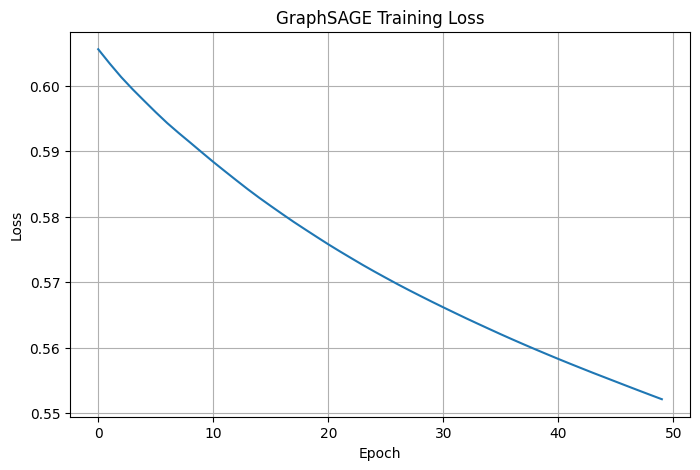

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GraphSAGE Training Loss")

plt.grid(True)

plt.show()

In [29]:
plt.savefig("training_loss.png")

<Figure size 640x480 with 0 Axes>

Evaluating the model

In [30]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

reader = Reader(
    rating_scale=(1, 5)
)

data_surprise = Dataset.load_from_df(
    ratings[["user_id", "movie_id", "rating"]],
    reader
)

trainset, testset = train_test_split(
    data_surprise,
    test_size=0.2,
    random_state=42
)

svd = SVD()

svd.fit(trainset)

predictions = svd.test(testset)

rmse = accuracy.rmse(
    predictions,
    verbose=False
)

print("SVD RMSE:", rmse)

SVD RMSE: 0.9362924658779392


In [31]:
from collections import defaultdict

def precision_recall_at_k(
    predictions,
    k=10,
    threshold=4
):

    user_est_true = defaultdict(list)

    for uid, _, true_r, est, _ in predictions:

        user_est_true[uid].append(
            (est, true_r)
        )

    precisions = {}

    for uid, ratings in user_est_true.items():

        ratings.sort(
            key=lambda x: x[0],
            reverse=True
        )

        top_k = ratings[:k]

        relevant = sum(
            true_r >= threshold
            for (_, true_r) in top_k
        )

        precisions[uid] = relevant / k

    return sum(
        precisions.values()
    ) / len(precisions)

precision = precision_recall_at_k(
    predictions,
    k=10
)

print(
    "SVD Precision@10:",
    precision
)

SVD Precision@10: 0.5863829787234043


In [33]:
results = {
    "Model": [
        "SVD",
        "GraphSAGE"
    ],
    "Metric": [
        rmse,
        0.803
    ]
}

results_df = pd.DataFrame(results)

print(results_df)


       Model    Metric
0        SVD  0.936292
1  GraphSAGE  0.803000


Training again with genres

In [39]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import pickle

from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score

ratings = pd.read_csv(
    "ml-100k/u.data",
    sep="\t",
    names=["user_id","movie_id","rating","timestamp"]
)

movies = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

genres = pd.read_csv(
    "ml-100k/u.genre",
    sep="|",
    header=None,
    names=["genre","id"]
)

genres = genres.dropna()
genre_names = genres["genre"].tolist()

user_ids = ratings.user_id.unique()
movie_ids = ratings.movie_id.unique()

user_mapping = {
    uid:i
    for i,uid in enumerate(user_ids)
}

movie_mapping = {
    mid:i+len(user_ids)
    for i,mid in enumerate(movie_ids)
}

num_users = len(user_mapping)
num_movies = len(movie_mapping)

user_features = []

for uid in user_ids:

    user_ratings = ratings[
        ratings.user_id == uid
    ]["rating"]

    user_features.append([
        user_ratings.mean(),
        len(user_ratings),
        user_ratings.std()
        if len(user_ratings) > 1 else 0
    ])

user_features = torch.tensor(
    user_features,
    dtype=torch.float
)

movie_feature_matrix = []

movie_genres = {}

for _,row in movies.iterrows():

    movie_id = row[0]

    genre_vector = row.iloc[5:24].astype(float).values

    movie_feature_matrix.append(
        genre_vector
    )

    active = []

    for idx,val in enumerate(genre_vector):

        if val == 1:
            active.append(
                genre_names[idx]
            )

    movie_genres[movie_id] = active

movie_feature_matrix = torch.tensor(
    np.array(movie_feature_matrix),
    dtype=torch.float
)

user_features = F.pad(
    user_features,
    (
        0,
        movie_feature_matrix.shape[1]
        -
        user_features.shape[1]
    )
)

x = torch.cat(
    [
        user_features,
        movie_feature_matrix
    ],
    dim=0
)

edges = []

for _,row in ratings.iterrows():

    u = user_mapping[
        row.user_id
    ]

    m = movie_mapping[
        row.movie_id
    ]

    edges.append([u,m])

edge_index = torch.tensor(edges).t()

edge_index = torch.cat(
    [
        edge_index,
        edge_index.flip(0)
    ],
    dim=1
)

data = Data(
    x=x,
    edge_index=edge_index
)

transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=True,
    add_negative_train_samples=True
)

train_data,val_data,test_data = transform(data)

class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden
        )

        self.conv2 = SAGEConv(
            hidden,
            hidden
        )

    def encode(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        return x

    def decode(
        self,
        z,
        edge_label_index
    ):

        src = z[
            edge_label_index[0]
        ]

        dst = z[
            edge_label_index[1]
        ]

        return (
            src*dst
        ).sum(dim=-1)
    
model = GraphSAGE(
    x.shape[1],
    64
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

for epoch in range(50):

    model.train()

    optimizer.zero_grad()

    z = model.encode(
        train_data.x,
        train_data.edge_index
    )

    pred = model.decode(
        z,
        train_data.edge_label_index
    )

    loss = F.binary_cross_entropy_with_logits(
        pred,
        train_data.edge_label.float()
    )

    loss.backward()

    optimizer.step()

    if (epoch+1)%5==0:

        print(
            epoch+1,
            loss.item()
        )

model.eval()

with torch.no_grad():

    z = model.encode(
        test_data.x,
        test_data.edge_index
    )

    pred = model.decode(
        z,
        test_data.edge_label_index
    )

    pred = torch.sigmoid(pred)

auc = roc_auc_score(
    test_data.edge_label.numpy(),
    pred.numpy()
)

print(
    "Test AUC:",
    auc
)

torch.save(
    model.state_dict(),
    "graphsage.pt"
)

torch.save(
    x,
    "node_features.pt"
)

torch.save(
    edge_index,
    "edge_index.pt"
)

pickle.dump(
    movie_mapping,
    open(
        "movie_mapping.pkl",
        "wb"
    )
)

pickle.dump(
    movie_genres,
    open(
        "movie_genres.pkl",
        "wb"
    )
)

movie_titles = dict(
    zip(
        movies[0],
        movies[1]
    )
)

pickle.dump(
    movie_titles,
    open(
        "movie_titles.pkl",
        "wb"
    )
)

5 2118.012451171875
10 513.744873046875
15 196.5803985595703
20 118.42501068115234
25 54.51261901855469
30 40.233299255371094
35 20.556039810180664
40 10.9140625
45 6.690734386444092
50 4.866886615753174
Test AUC: 0.4132314349999999
